In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [4]:
# 1. DATASET PIPELINE (Incorporating the shuffle=False fix for the Test set)
TRAIN_DIR = "chest_xray/train"
VAL_DIR = "chest_xray/val"
TEST_DIR = "chest_xray/test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# CRITICAL: shuffle=False guarantees our y_true arrays line up with model.predict()
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [5]:
# 2. MODEL ARCHITECTURE (With embedded On-The-Fly Augmentation)

# Slight random tilt (+/- 5%) and zoom to prevent Dense Layer memorization
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05, fill_mode="nearest"),
    layers.RandomZoom(height_factor=(-0.05, 0.05), fill_mode="nearest"),
], name="augmentation_block")

ann_model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Rescaling(1./255),
    
    # Augmentation is only active during .fit(), it automatically turns off during .predict()
    data_augmentation,
    
    layers.Flatten(),
    
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dense(1, activation="sigmoid")
])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_block (Sequential) │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,565,249 (32.67 MB)

 Trainable params: 8,563,457 (32.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [6]:
# 3. DUAL-CALLBACK SCHEDULER SETUP

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# If Val Loss doesn't drop for 2 rounds, cut Learning Rate by 50%
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# If Val loss doesn't drop for 5 rounds, kill training and roll back weights
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [7]:
# 4. EXECUTE TRAINING
history = ann_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.8620 - loss: 0.3184 - val_accuracy: 0.6250 - val_loss: 1.6595 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9124 - loss: 0.2144 - val_accuracy: 0.6875 - val_loss: 1.1612 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9193 - loss: 0.1981 - val_accuracy: 0.6250 - val_loss: 1.0356 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9256 - loss: 0.1854 - val_accuracy: 0.6875 - val_loss: 1.0233 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9340 - loss: 0.1757 - val_accuracy: 0.4375 - val_loss: 1.5436 - learning_rate: 0.0010
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9385 - loss: 0.1590
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9344 - loss

In [8]:
# 5. SCIKIT-LEARN DIAGNOSTICS (Ported from cell 36 of your PyTorch file)

print("\nExecuting vectorized test set predictions...")

# Extract ground-truth labels sequentially
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Generate raw float predictions (e.g. 0.841) and lock them to 0 or 1
y_pred_probs = ann_model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).squeeze()

target_names = ["Normal (0)", "Pneumonia (1)"]

print("\n" + "="*50)
print("     DEEP ANN CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names))


Executing vectorized test set predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

     DEEP ANN CLASSIFICATION REPORT
               precision    recall  f1-score   support

   Normal (0)       0.92      0.59      0.72       234
Pneumonia (1)       0.80      0.97      0.88       390

     accuracy                           0.83       624
    macro avg       0.86      0.78      0.80       624
 weighted avg       0.84      0.83      0.82       624



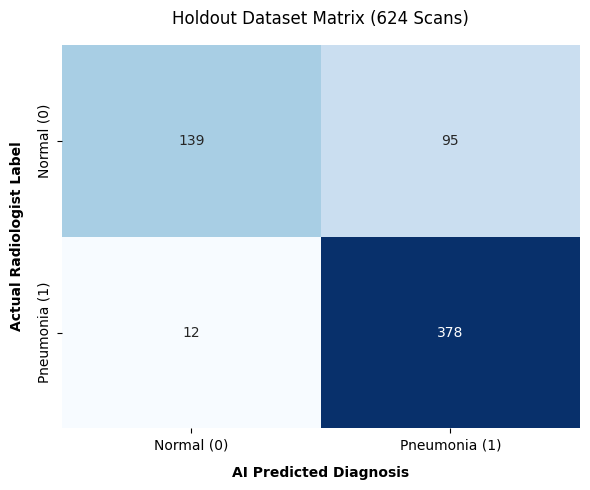


[SUCCESS] Model saved to disk as 'deep_ann_pneumonia.keras'


In [9]:
# 6. SEABORN CONFUSION MATRIX (Ported from cell 37 of your PyTorch file)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False
)
plt.xlabel("AI Predicted Diagnosis", fontweight="bold", labelpad=10)
plt.ylabel("Actual Radiologist Label", fontweight="bold", labelpad=10)
plt.title("Holdout Dataset Matrix (624 Scans)", pad=15)
plt.tight_layout()
plt.show()

# Save final weights for Streamlit consumption
ann_model.save("deep_ann_pneumonia.keras")
print("\n[SUCCESS] Model saved to disk as 'deep_ann_pneumonia.keras'") 